# Grade: 100 points

# Assignment 02: Classification with Ridge, LASSO, and Feedforward Neural Networks

## Instructions

#### Follow these steps before submitting your assignment :

1. Complete the notebook.

2. Make sure all plots have axis labels.

3. Once the notebook is complete, `Restart` your kernel by clicking 'Kernel' > 'Restart & Run All'.

4. Fix any errors until your notebook runs without any problems.

5. Please note, a random seed of 42 needs to be set to ensure the reproducability of the results -- *DO NOT* change this random seed. **If you call additional functions that are based on random number generators, you will need to define their seed to 42 as well**.

6. Make sure to reference all external code and documentation used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
roc_auc_score, roc_curve, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Suppress overflow warnings from sklearn/numpy
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(over='ignore')

sns.set(style='whitegrid', context='notebook')

#Check device for NN
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Q1 - Data Loading and Exploration

[This Kaggle dataset](https://www.kaggle.com/competitions/titanic) contains data on passengers of the famous Titanic disaster. The task is to examine and predict what sorts of people were more likely to survive using data on their name, age, gender, socio-economic class, etc.

#### 1. Loading our Data
Load the train and test data into a pandas dataframe and display the first few rows using ``.head()``

In [2]:
#Q1.1
train_data=pd.read_csv('train.csv')
print("First five lines:")
print(train_data.head())

First five lines:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

#### 2. Checking for Null Values
Check for null values in the training data using ``.isnull().sum()``

In [3]:
#Q1.2
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### 3. Visualizing Null Values

Create a seaborn heatmap that displays all of the null data using ``sns.heatmap(train.isnull(), cbar=False)`` to get a visual representation on how much data is missing for each variable.

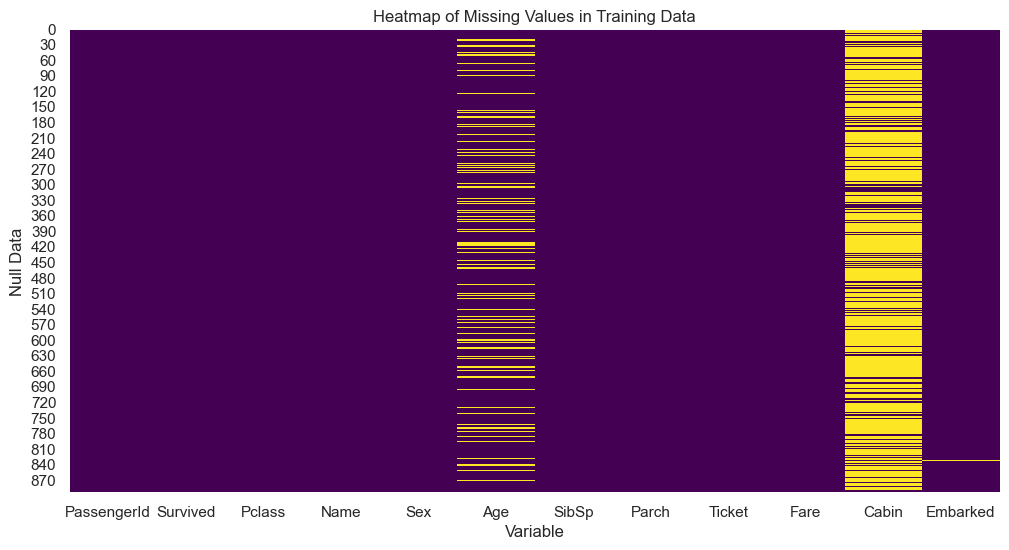

In [4]:
#Q1.3
plt.figure(figsize=(12, 6))
sns.heatmap(train_data.isnull(), cbar=False, cmap='viridis')
plt.xlabel('Variable')
plt.ylabel('Null Data')
plt.title("Heatmap of Missing Values in Training Data")
plt.show()

#### 4a. Visualizing Survival vs. Sex

Create a seaborn barplot that compares 'Survival Rate by Sex', where x is 'Sex' and y is 'Survived' from the training data.

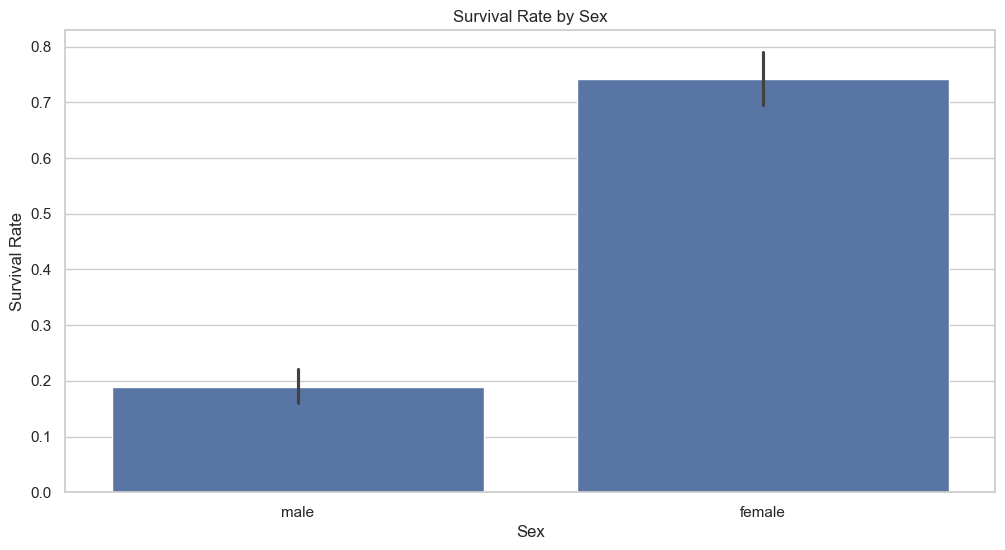

In [5]:
#Q1.4a
plt.figure(figsize=(12,6))
sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

#### 4b. Visualizing Survival vs. Passenger Class
Create another barplot for 'Survival Rate by Passenger Class' (the `Pclass` variable).

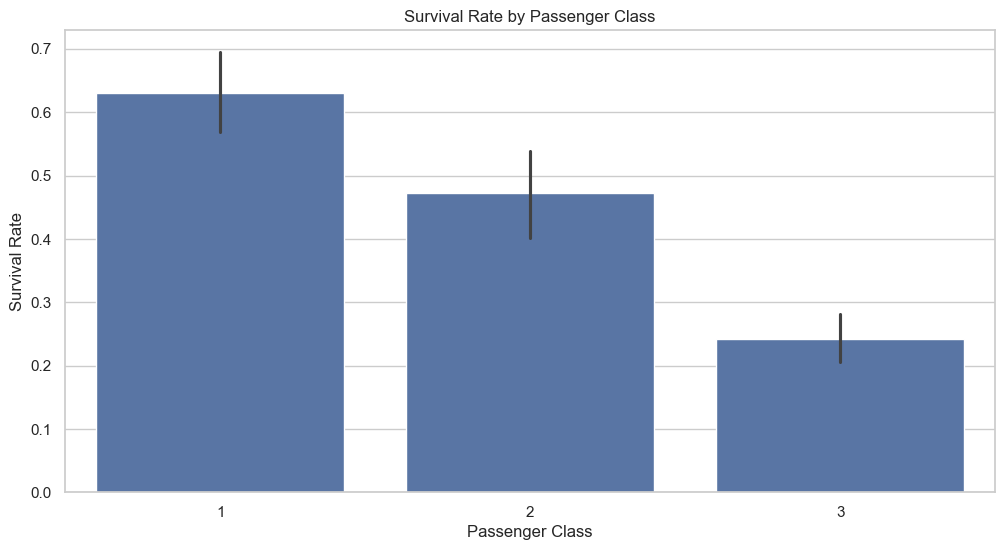

In [6]:
#Q1.4b
plt.figure(figsize=(12,6))
sns.barplot(x='Pclass', y='Survived', data=train_data)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

#### 5. Visualizing Age Distribution by Survival

Create a seaborn a stacked histogram for 'Age Distribution by Survival'. x is 'Age', and one histogram should be for 'Survived'=0, and the other for 'Survived'=1. Use a bin size of 20.

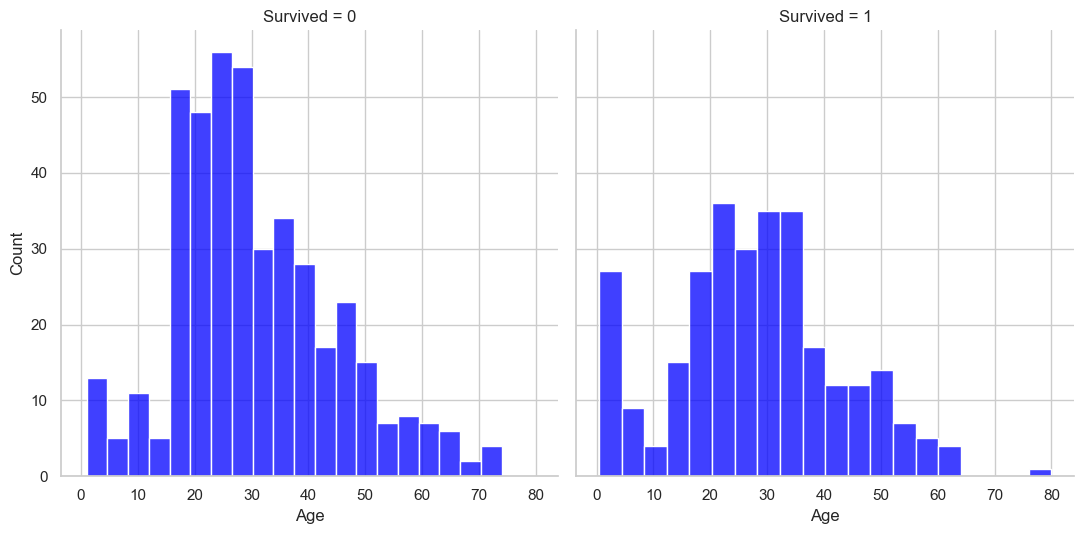

In [7]:
#Q1.5
g=sns.FacetGrid(train_data, col='Survived', height=5.5, aspect=1)
g.map(sns.histplot, 'Age', bins=20, color='blue')
g.set_axis_labels('Age', 'Count')
g.set_titles('Survived = {col_name}')
plt.show()

#### 6. Feature Correlation

Create a seaborn heatmap: 'Feature Correlation Heatmap' which displays only numeric variables. The result should contain 7 variables. Although we will not be doing so in this assignment, noting which variables are most highly correlated can inform our decisions on feature engineering. We will discuss this further in assignment 3.

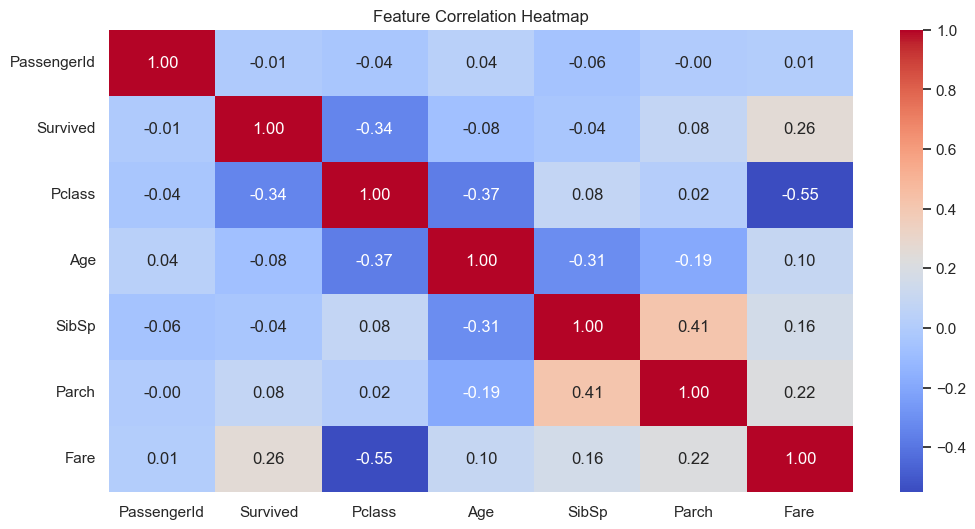

In [8]:
#Q1.6
numeric_data = train_data.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# Q2 - Feature Engineering

In this section, you will engineer new features from the Titanic dataset to help your model capture more meaningful relationships.

Use **pandas** functions such as:
- `.apply()`
- `.replace()`
- `.groupby()`
- `.median()`
- `.fillna()`
- `.map()`
- `.get_dummies()`
- `.astype()`

Follow the outline below and implement each transformation step-by-step.


#### 1. Extract Titles from Passenger Names
Each passenger’s `Name` contains a title (e.g., *Mr.*, *Mrs.*, *Miss.*, *Dr.*, etc.).  
- Use `.apply()` with a helper function to extract each passenger’s title from the `Name` column.  
- Combine less common titles ('Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona') into a single category called `"Rare"`.  
  - You can do this efficiently with `.replace()`.

In [9]:
import re

# Extract Title from Name
def extract_title(name):
    m = re.search(r',\s*([^\.]+)\.', name)
    return m.group(1) if m else 'Unknown'

#Q2.1
train_data['Title']=train_data['Name'].apply(extract_title)
print(train_data['Title'].unique())
rare_titles=['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
train_data['Title'] = train_data['Title'].replace(rare_titles, 'Rare')
print(train_data['Title'].value_counts())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']
Title
Mr              517
Miss            182
Mrs             125
Master           40
Rare             22
Mlle              2
Mme               1
Ms                1
the Countess      1
Name: count, dtype: int64


#### 2. Create Family-Based Features
We can capture social context by adding two new features:
- **`FamilySize`**: total number of family members aboard (siblings/spouses + parents/children + 1 for the passenger).  
- **`IsAlone`**: binary indicator (`1` if alone, `0` otherwise).  

To do this:
- Use arithmetic operations on existing columns (`SibSp`, `Parch`) to create `FamilySize`.  
- Create `IsAlone` using a boolean condition and then convert it to an integer with `.astype(int)`.

In [10]:
#Q2.2
train_data['FamilySize']=train_data['SibSp']+train_data['Parch']+1
print(train_data['FamilySize'].value_counts())
train_data['IsAlone']=(train_data['FamilySize']==1).astype(int)
print(train_data['IsAlone'].value_counts())

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64
IsAlone
1    537
0    354
Name: count, dtype: int64


#### 3. Impute Missing Ages
Instead of using a single median for all passengers, compute a **median Age per Title**.  
Then fill in missing Age values using that median for the passenger’s title group.

You’ll need to:
- Use `.groupby()` on the `Title` column and compute `.median()` for `Age`.  
- Use `.apply()` (with a `lambda` function) to fill in missing `Age` values row by row.

In [11]:
#Q2.3
title_age_median = train_data.groupby('Title')['Age'].median()
print("median Age per Title:")
print(title_age_median)
train_data['Age']=train_data.apply(
    lambda row: title_age_median[row['Title']] if pd.isnull(row['Age']) else row['Age'],
    axis=1
)
print("Number of Null after filling:{train_data['Age'].isnull().sum()}")

median Age per Title:
Title
Master           3.5
Miss            21.0
Mlle            24.0
Mme             24.0
Mr              30.0
Mrs             35.0
Ms              28.0
Rare            49.0
the Countess    33.0
Name: Age, dtype: float64
Number of Null after filling:{train_data['Age'].isnull().sum()}


#### 4. Fill Missing Fares
Fill missing `Fare` values with the overall median fare of the dataset using `.fillna()`.

In [12]:
#Q2.4
overall_fare_median=train_data['Fare'].median()
print(f"\nmedian fare: {overall_fare_median:.2f}")
train_data['Fare']=train_data['Fare'].fillna(overall_fare_median)
print(f"Number of Null after filling: {train_data['Fare'].isnull().sum()}")


median fare: 14.45
Number of Null after filling: 0


#### 5. Encode Categorical Variables
Machine learning models need numeric features. Convert categorical features into numeric form:
- Convert `Sex` into 0/1 values using `.map()`.  
- One-hot encode `Embarked` into dummy variables (e.g., `Embarked_C`, `Embarked_Q`, `Embarked_S`) using `pd.get_dummies()` with the `columns` argument.

In [13]:
#Q2.5
train_data['Sex']=train_data['Sex'].map({'male': 0, 'female': 1})
print(train_data['Sex'].value_counts())
embarked_dummies = pd.get_dummies(train_data['Embarked'], prefix='Embarked')
print(embarked_dummies.head())
train_data = pd.concat([train_data, embarked_dummies], axis=1)
print("\ncolumn names:")
print(train_data.columns.tolist())

Sex
0    577
1    314
Name: count, dtype: int64
   Embarked_C  Embarked_Q  Embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True

column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


#### 6. Define Your Feature Set
Create your final feature matrix `X` and label vector `y`.  
Select a combination of numerical and engineered features (e.g., `Pclass`, `Sex`, `Age`, `Fare`, `FamilySize`, `IsAlone`, `Embarked`(_C, _Q, _S) columns).

Use `X.head()` to verify your final dataset looks correct.

In [14]:
#Q2.6
y = train_data['Survived']
X = train_data[['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S']]
X.head()

,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,7.2500,2,0,False,False,True
1,1,1,38.0,71.2833,2,0,True,False,False
2,3,1,26.0,7.9250,1,1,False,False,True
3,1,1,35.0,53.1000,2,0,False,False,True
4,3,0,35.0,8.0500,1,1,False,False,True


# Q3 - Train/Test Split and Feature Scaling

Now that you’ve finished feature engineering, it’s time to prepare the data for modeling.  
This step ensures that your model generalizes well and that all numeric features are on a similar scale.


#### 1. Split the Data
Use the **`train_test_split()`** function from `sklearn.model_selection` to divide your data into:
- **Training set (80%)**
- **Testing set (20%)**

Make sure to:
- Use the `stratify` parameter to preserve the class balance of the target variable (`y`).
- Set a fixed `random_state` so results are reproducible.

In [15]:
#Q3.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### 2. Scale the Numeric Features
Feature scaling helps models converge faster and prevents some features from dominating others.

- Use `StandardScaler` from `sklearn.preprocessing` to **standardize** numeric columns such as `Age`, `Fare`, and `FamilySize`.
- Remember to **fit the scaler only on the training data** and then **transform both** the training and test sets.
  - Functions to use: `.fit()` and `.transform()`
- Overwrite the scaled columns in both `X_train` and `X_test`.

In [16]:
#Q3.2
num_cols = ['Age', 'Fare', 'FamilySize']
scaler = StandardScaler()
scaler.fit(X_train[num_cols])
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
print(X_train[num_cols].head())

          Age      Fare  FamilySize
692  0.036020  0.513812   -0.556339
481  0.036020 -0.662563   -0.556339
527  0.036020  3.955399   -0.556339
855 -0.868936 -0.467874    0.073412
801  0.111433 -0.115977    0.703162


#### 3. Prepare Data for PyTorch
PyTorch expects input data as floating-point numbers (`float32`).  
Also, boolean columns (`True`/`False`) need to be converted to numeric values (1.0 and 0.0).

Use **`.astype(np.float32)`** on both `X_train` and `X_test` to ensure all features are numeric and compatible with tensors.

In [17]:
#Q3.3 Cast bools to 1.0 for true, and 0.0 for false
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)
print(X_train.dtypes.head())

Pclass        float32
Sex           float32
Age           float32
Fare          float32
FamilySize    float32
dtype: object


# Q4 - Training LASSO and Ridge


#### 1. Define the Models
Create two logistic regression models:
- **LASSO (L1 Regularization):**
  - Use the parameter `penalty='l1'`
  - Requires the `solver='liblinear'`
- **Ridge (L2 Regularization):**
  - Use the parameter `penalty='l2'`
  - A good solver choice is `'lbfgs'`
- Set `max_iter` high enough (e.g., 1000) to ensure convergence.


In [18]:
#Q4.1
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
ridge_model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

#### 2. Train (Fit) Each Model
Use the `.fit()` method to train both models on your **training data** (`X_train`, `y_train`).

In [19]:
#Q4.2
lasso_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### 3. Make Predictions
Use `.predict_proba()` on the **test set** to get predicted probabilities for the positive class (`Survived = 1`).

You’ll then:
- Extract the second column (the probability of class 1)
- Convert these probabilities to binary predictions (`0` or `1`) using a threshold of 0.5  
  - You can do this using array comparison and `.astype(int)`

Predict 1 if probability > 0.5 else predict 0.

In [20]:
#Q4.3
lasso_probs = lasso_model.predict_proba(X_test)[:, 1]
ridge_probs = ridge_model.predict_proba(X_test)[:, 1]
lasso_preds = (lasso_probs > 0.5).astype(int)
ridge_preds = (ridge_probs > 0.5).astype(int)
print("LASSO predictions:", lasso_preds[:10])
print("Ridge predictions:", ridge_preds[:10])

LASSO predictions: [0 0 0 0 1 1 1 0 0 0]
Ridge predictions: [0 0 0 0 1 1 1 0 0 0]


Run the following for evaluation metrics for both of these models.

LASSO Logistic Regression → Accuracy: 0.7933, F1: 0.7176, ROC AUC: 0.8524
Ridge Logistic Regression → Accuracy: 0.8045, F1: 0.7328, ROC AUC: 0.8520


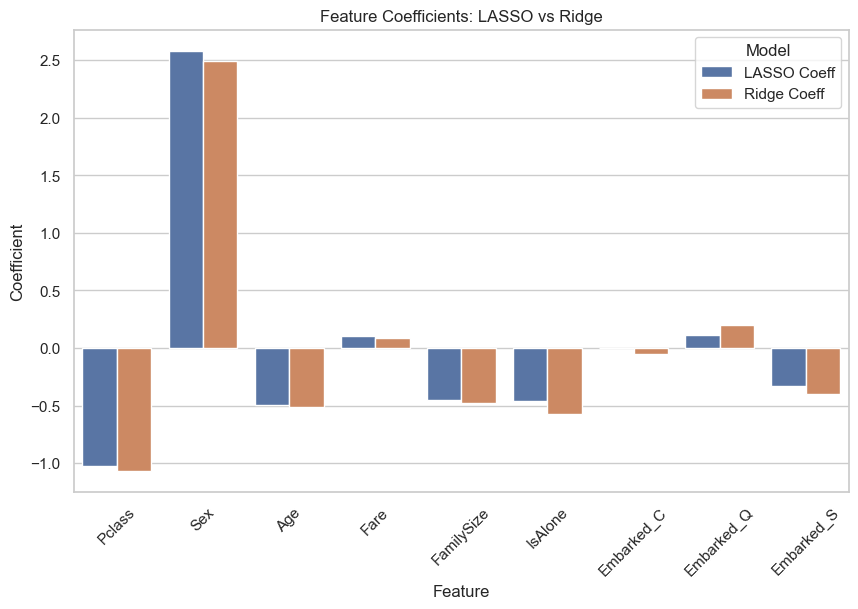

In [21]:
# Metrics
def evaluate_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}, ROC AUC: {auc:.4f}")

evaluate_model('LASSO Logistic Regression', y_test, lasso_preds, lasso_probs)
evaluate_model('Ridge Logistic Regression', y_test, ridge_preds, ridge_probs)

features = X.columns

# Coefficient comparison
coeff_df = pd.DataFrame({
'Feature': features,
'LASSO Coeff': lasso_model.coef_[0],
'Ridge Coeff': ridge_model.coef_[0]
})

coeff_df_melted = coeff_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
plt.figure(figsize=(10,6))
sns.barplot(data=coeff_df_melted, x='Feature', y='Coefficient', hue='Model')
plt.xticks(rotation=45)
plt.title('Feature Coefficients: LASSO vs Ridge')
plt.show()

# Q5 - Training a Neural Network

Convert the datasets to tensors for Pytorch.

In [22]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

Define our NN Model.

In [23]:
class TitanicNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = TitanicNet(X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#### 1. Define your Training Loop

Inside your training loop, for each batch of data from the DataLoader, you’ll need to perform the core operations that allow your neural network to learn.  

At a high level, each batch should follow this sequence:

1. **Reset accumulated gradients** — before processing a new batch, clear any gradients stored from the previous iteration using the appropriate optimizer method.  
2. **Forward pass** — pass the batch of input data through the model to obtain predicted outputs (often called *logits*).  
3. **Compute the loss** — use your chosen loss function (*criterion* in the cell above) to compare the predictions with the actual target labels.  
4. **Backpropagation** — compute gradients of the loss with respect to the model’s parameters.  
5. **Parameter update** — use the optimizer to apply those gradients and update the model weights.

Each of these steps corresponds to a single PyTorch function call, and they must occur in this exact order for the model to train correctly.


In [24]:
num_epochs = 50
train_losses, train_accs = [], []

for epoch in range(num_epochs):
    model.train()
    total_loss, total_correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        #Q5.1 Add training code here
        optimizer.zero_grad()
        logits=model(xb)
        loss=criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * xb.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        total_correct += (preds == yb).sum().item()
        total += xb.size(0)

        train_loss = total_loss / total
        train_acc = total_correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")

Epoch 10/50: train_loss=0.4224, train_acc=0.8146
Epoch 20/50: train_loss=0.3985, train_acc=0.8329
Epoch 30/50: train_loss=0.3893, train_acc=0.8371
Epoch 40/50: train_loss=0.3847, train_acc=0.8357
Epoch 50/50: train_loss=0.3781, train_acc=0.8539


Plot training loss and accuracy.

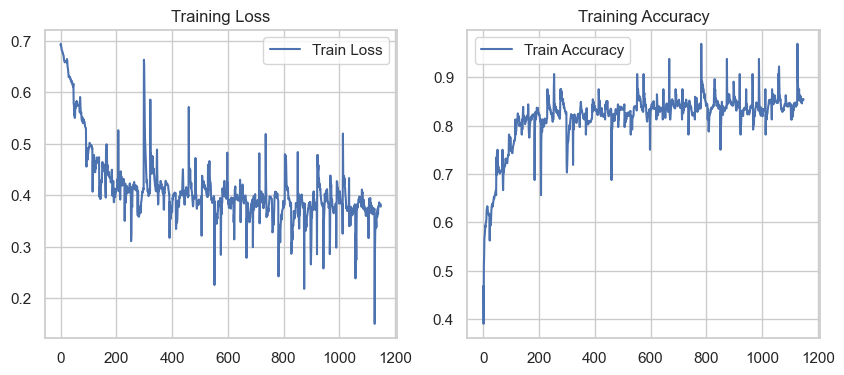

In [25]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

Plot training loss and accuracy again, but smoothed so we can see overall trends more easily.

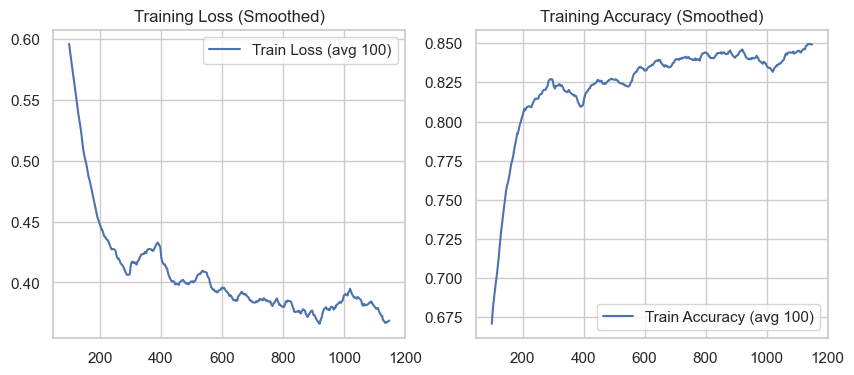

In [26]:
window = 100  # moving average window
smoothed_acc = pd.Series(train_accs).rolling(window).mean()
smoothed_loss = pd.Series(train_losses).rolling(window).mean()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(smoothed_loss, label=f'Train Loss (avg {window})')
plt.title('Training Loss (Smoothed)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(smoothed_acc, label=f'Train Accuracy (avg {window})')
plt.title('Training Accuracy (Smoothed)')
plt.legend()
plt.show()

Report evaluation metrics just like we did for LASSO and Ridge.

In [27]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device)).cpu().numpy().flatten()

probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds)
rec = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
roc_auc = roc_auc_score(y_test, probs)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.8101
Precision: 0.8723
Recall: 0.5942
F1 Score: 0.7069
ROC AUC: 0.8548


#### 2. ROC Curve (Receiver Operating Characteristic)

The **ROC curve** shows the trade-off between the **True Positive Rate (TPR)** and the **False Positive Rate (FPR)** at various classification thresholds.

- Use `roc_curve()` from `sklearn.metrics` to calculate the `fpr` and `tpr` values.
- Plot these values using `matplotlib.pyplot` to visualize your model’s ability to distinguish between classes.
- Add an **AUC (Area Under the Curve)** score to your plot legend to summarize overall performance.

A higher AUC (closer to 1.0) means your model is better at distinguishing survivors from non-survivors.

Include:
- `plt.plot()` for the ROC line  
- Axis labels (`plt.xlabel`, `plt.ylabel`)  
- A title and legend for clarity


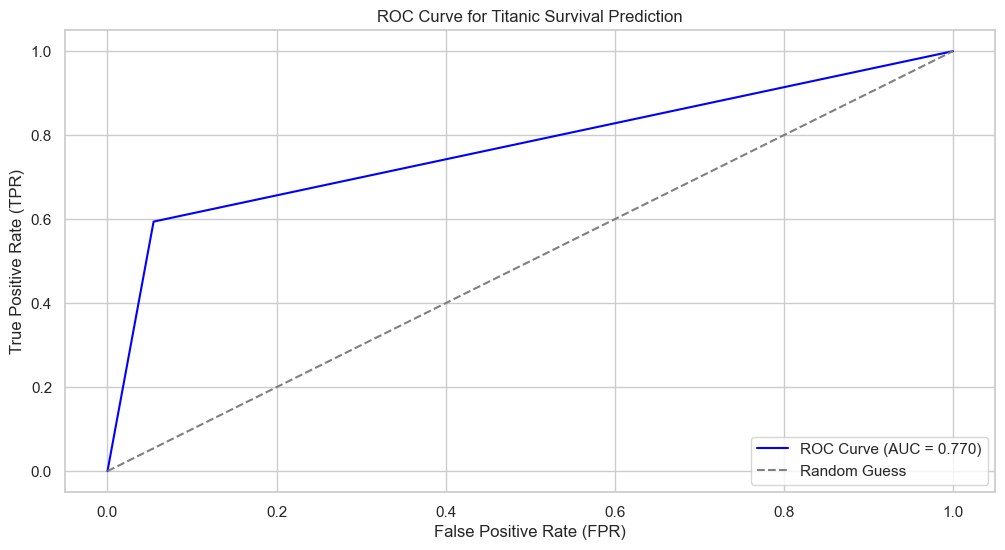

In [28]:
#Q5.2
fpr, tpr, thresholds = roc_curve(y_test, preds)
auc_score = roc_auc_score(y_test, preds)
plt.figure(figsize=(12,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Titanic Survival Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### 3. Confusion Matrix

A **confusion matrix** shows how many predictions were correct versus incorrect for each class.

- Use `confusion_matrix()` from `sklearn.metrics` to generate the matrix.
- Then use `seaborn.heatmap()` to visualize it in an easy-to-read grid format.
- Label the axes to clearly indicate which side represents predicted vs. actual values.

Set `annot=True` to display the numbers inside the boxes and use a color map (e.g., `'Blues'`) for better contrast.

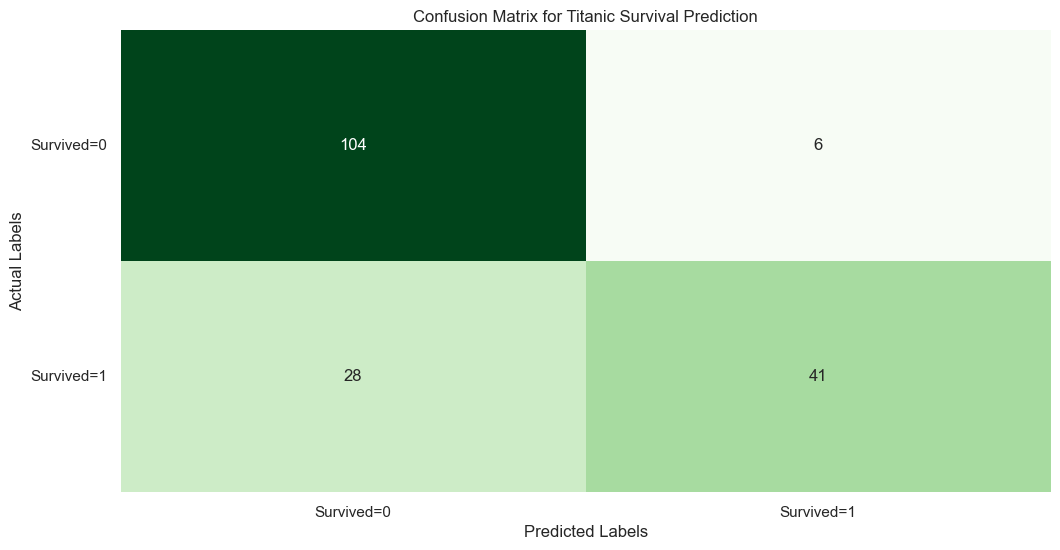

In [29]:
#Q5.3
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix for Titanic Survival Prediction')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.xticks([0.5, 1.5], ['Survived=0', 'Survived=1'])
plt.yticks([0.5, 1.5], ['Survived=0', 'Survived=1'], rotation=0)
plt.show()